# Barcelona Accidentes + Meteorología — Pipeline de Búsqueda de Patrones SPARQL

**Zona de Explotación del KG · Proyecto Final de Universidad**

Este notebook documenta y **ejecuta en vivo** un pipeline de búsqueda de patrones SPARQL
sobre un grafo de conocimiento (KG) construido a partir de los registros de accidentes de
tráfico de Barcelona y las lecturas de las estaciones meteorológicas.

## Objetivo

La *zona de explotación* toma los datos relacionales de origen — ya convertidos en un
**grafo de conocimiento** en una etapa anterior — y ejecuta **analíticas de búsqueda de
patrones en grafo (SPARQL)** para:

1. **Detectar posibles fraudes en accidentes / anomalías de calidad de datos** emparejando
   *motivos* sospechosos del grafo (informes duplicados co-localizados, perfiles
   demográficos recurrentes, inconsistencias entre gravedad y heridos).
2. **Responder preguntas de investigación abstractas y multi-salto** que resultan incómodas
   sobre tablas planas pero naturales sobre un grafo (puntos negros por calle, gravedad por
   distrito y hora, exposición de usuarios vulnerables, y un puente meteorología/accidentes
   entre subgrafos).

Se plantean siete preguntas analíticas (Q1–Q7). Para cada una indicamos el **objetivo**
(señal de fraude vs. pregunta de investigación), mostramos el **motivo SPARQL**, lo
**ejecutamos en vivo** contra el grafo en memoria, **visualizamos** el resultado (subgrafos
nodo-enlace para las consultas estructurales de fraude; gráficos para las consultas
analíticas), e **interpretamos** el resultado.


## 1. Visión general del grafo de conocimiento

El KG fue creado en **WebProtégé**, por lo que cada término del esquema es un IRI *opaco*
bajo el espacio de nombres `wp: <http://webprotege.stanford.edu/>` (p. ej. la clase
*Accidente* es `wp:RDHGr7pl4B25glJmq2xYYmN`). Un módulo de configuración complementario
(`config/ontology.py`) mapea cada IRI opaco a un **nombre legible**, de modo que ni este
notebook ni las consultas codifican cadenas `R...` crudas más allá de los ficheros `.rq`.

### Dos subgrafos, ahora conectados por `CloserStation`

El ABOX (instancias) contiene dos grandes regiones — **accidentes** y **meteorología** —
que históricamente eran **dos componentes conexas sin ninguna arista en común**. Los
compañeros de equipo han añadido una **nueva propiedad de objeto `CloserStation`**
(`Accidente —CloserStation→ EstacionMeteorologica`), materializada sobre **7.599 de los
7.741 accidentes** (la estación más cercana: **X4 = 5.396 · D5 = 1.394 · X8 = 809**;
~142 accidentes aún sin asignar). Esta arista **conecta por fin ambos subgrafos**: cada
accidente apunta a su estación meteorológica más próxima.

| Subgrafo | Forma | Propiedades de datos clave |
|----------|-------|---------------------|
| **Accidentes** | `Persona —InvolucradoEn→ Accidente —UbicadoEn→ Lugar` | `Accidente`: `FechadoEn`, `NumFeritLleu/Greu`, `NumMort`, `AccidentID`; `Lugar`: `Distrito/Barrio/Calle`; `Persona`: `Edad/Sexo/VehicleImplicat` |
| **Meteorología** | `EstacionMeteorologica —Medir→ LecturaMeteorologica` | `Valor`, `Acronimo` (15 códigos de medida), `FechadoEn` |
| **Puente (NUEVO)** | `Accidente —CloserStation→ EstacionMeteorologica` | arista espacial: estación más cercana a cada accidente |

`Accidente` tiene cuatro subtipos: **Leve / Grave / Mortal / SinVictima**.
Hay **3 estaciones meteorológicas** (D5, X4, X8).

> **La fecha (`FechadoEn`) sigue siendo una dimensión compartida**, pero ya **no es el
> único nexo**: ahora existe **también una arista espacial real** (`CloserStation`) que
> vincula cada accidente con su estación más cercana. Esto habilita dos análisis nuevos:
> el reparto de accidentes por cuenca de estación (**Q8**, recorrido puro en el grafo) y un
> puente meteorológico **consciente de la ubicación** (**Q9**), que sustituye al puente
> Q7 basado solo en la fecha — véase §3 y el informe técnico.

### Recuento de instancias (del EDA)

| Entidad | Recuento | Desglose |
|--------|-------|-----------|
| `Accidente` | **7.741** | Leve 6.599 · SinVictima 890 · Grave 241 · **Mortal 11** |
| `Persona` | **16.001** | Conductor 14.126 · Passatger 2.009 · Vianant 1.065 |
| `Lugar` | **4.386** | distrito / barrio / calle |
| `EstacionMeteorologica` | **3** | D5, X4, X8 |
| `LecturaMeteorologica` | **~16.000** | 15 medidas diarias, año completo 2025 |
| `CloserStation` (aristas) | **7.599** | X4 5.396 · D5 1.394 · X8 809 (~142 accidentes sin asignar) |
| **Triples totales** | **≈ 265.197** | (eran ≈ 257.593 antes de `CloserStation`) |

El TTL es **autocontenido**: incrusta el TBOX (incluidas las `rdfs:label`), de modo que las
búsquedas de etiquetas de clase (usadas por Q3/Q5/Q6) funcionan cargando **solo** el TTL.
Las fechas se mantienen como `xsd:dateTimeStamp`.

### Esquema de la forma a nivel de TBOX

La celda siguiente dibuja la forma del *esquema* (a nivel de clase) de ambos subgrafos y su
desconexión — no el grafo de instancias de 257k triples, solo el motivo que recorre cada consulta.

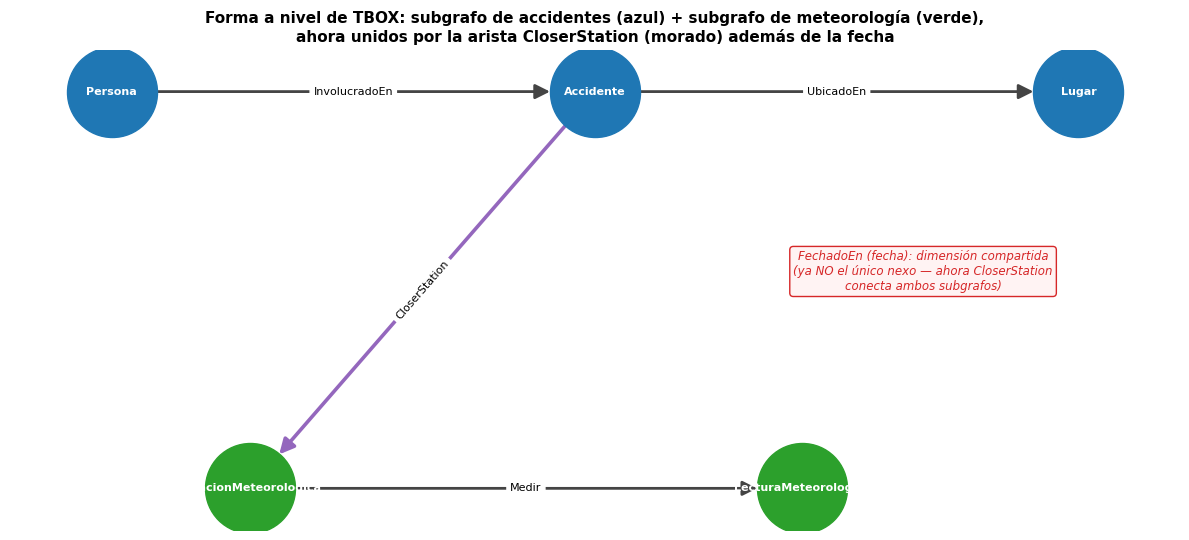

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

fig, ax = plt.subplots(figsize=(12, 5.5))
G = nx.DiGraph()
# subgrafo de accidentes
G.add_edge("Persona", "Accidente", label="InvolucradoEn")
G.add_edge("Accidente", "Lugar", label="UbicadoEn")
# subgrafo de meteorología
G.add_edge("EstacionMeteorologica", "LecturaMeteorologica", label="Medir")
# NUEVA arista que conecta ambos subgrafos: la estación más cercana a cada accidente
G.add_edge("Accidente", "EstacionMeteorologica", label="CloserStation")

pos = {
    "Persona": (0.0, 1.0), "Accidente": (1.4, 1.0), "Lugar": (2.8, 1.0),
    "EstacionMeteorologica": (0.4, 0.0), "LecturaMeteorologica": (2.0, 0.0),
}
acc_nodes = ["Persona", "Accidente", "Lugar"]
wx_nodes = ["EstacionMeteorologica", "LecturaMeteorologica"]
nx.draw_networkx_nodes(G, pos, nodelist=acc_nodes, node_color="#1f77b4",
                       node_size=4200, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=wx_nodes, node_color="#2ca02c",
                       node_size=4200, ax=ax)
# arista CloserStation resaltada en morado (el nuevo puente entre subgrafos)
nx.draw_networkx_edges(G, pos, edgelist=[("Accidente", "EstacionMeteorologica")],
                       ax=ax, arrowsize=22, width=2.6, edge_color="#9467bd",
                       node_size=4200)
nx.draw_networkx_edges(G, pos,
                       edgelist=[("Persona", "Accidente"), ("Accidente", "Lugar"),
                                 ("EstacionMeteorologica", "LecturaMeteorologica")],
                       ax=ax, arrowsize=22, width=2, edge_color="#444", node_size=4200)
nx.draw_networkx_labels(G, pos, font_size=8, font_color="white",
                        font_weight="bold", ax=ax)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G, "label"),
                             font_size=8, ax=ax)
# la fecha sigue siendo una dimensión compartida, pero ya no es el único nexo
ax.annotate("FechadoEn (fecha): dimensión compartida\n(ya NO el único nexo — ahora "
            "CloserStation\nconecta ambos subgrafos)",
            xy=(2.35, 0.5), ha="center", fontsize=8.5, style="italic", color="#d62728",
            bbox=dict(boxstyle="round", fc="#fff3f3", ec="#d62728"))
ax.set_title("Forma a nivel de TBOX: subgrafo de accidentes (azul) + subgrafo de meteorología "
             "(verde),\nahora unidos por la arista CloserStation (morado) además de la fecha",
             fontsize=11, fontweight="bold")
ax.axis("off"); plt.tight_layout(); plt.show()

## 2. Preparación

Añadimos el directorio de la zona de explotación a `sys.path` e importamos el módulo
compartido `config.ontology` (mapas legible→IRI, `PREFIXES`, `TTL_FILE`, `MEASURE_CODES`).
Después definimos un ayudante `run_query(name)` que lee un fichero `.rq` y lo ejecuta sobre
el grafo **cargado una sola vez**, devolviendo un `DataFrame` de pandas.

In [2]:
import sys, time
from pathlib import Path
import pandas as pd
import rdflib

ZONE_DIR = Path(r"C:\UPC\BCN-Meteorologics\KG_exploit_zone")
sys.path.insert(0, str(ZONE_DIR))
from config import ontology as O   # readable->IRI maps, PREFIXES, TTL_FILE, MEASURE_CODES

QUERIES_DIR = ZONE_DIR / "sparql_pipeline" / "queries"
print("rdflib", rdflib.__version__, "| pandas", pd.__version__)
print("TTL:", O.TTL_FILE.name, "| dir. consultas:", QUERIES_DIR.relative_to(ZONE_DIR))

rdflib 7.6.0 | pandas 2.3.3
TTL: kg_accidentes_bcn.ttl | dir. consultas: sparql_pipeline\queries


### Cargar el grafo **una sola vez** (~6–16 s)

Cargar el TTL de 257k triples es el único paso lento. Lo hacemos **una única vez** y
reutilizamos el mismo `rdflib.Graph` para cada consulta — re-parsear por consulta sería un
desperdicio, y un producto cartesiano plano accidentes×lecturas *colgaría* rdflib (evitado
por diseño; véase el informe técnico).

In [3]:
g = rdflib.Graph()
_t0 = time.time()
g.parse(str(O.TTL_FILE), format="turtle")
PARSE_SECONDS = time.time() - _t0
print(f"Cargados {len(g):,} triples en {PARSE_SECONDS:.1f}s")

Cargados 265,197 triples en 6.3s


### El ayudante `run_query`

La selección de backend refleja el ejecutor de producción `run_sparql.py`: **GraphDB es el
backend recomendado** (endpoint SPARQL HTTP escalable), con un **fallback en memoria con
rdflib** que no necesita servidor. Sondeamos si hay un GraphDB en ejecución; si no lo hay,
usamos el grafo rdflib ya cargado. En cualquier caso, `run_query` devuelve un `DataFrame`
ordenado y registra el tiempo de reloj por consulta en `QUERY_TIMES`.

In [4]:
import urllib.request

def graphdb_available() -> bool:
    try:
        with urllib.request.urlopen(O.GRAPHDB_BASE + "/rest/repositories", timeout=2) as r:
            return r.status == 200
    except Exception:
        return False

BACKEND = "graphdb" if graphdb_available() else "rdflib"
print(f"Backend autoseleccionado: {BACKEND}"
      + ("" if BACKEND == "graphdb" else "  (no se detectó servidor GraphDB -> rdflib en memoria)"))

QUERY_TIMES = {}

def read_query(name: str) -> str:
    'Devuelve el texto SPARQL crudo de queries/<name>.rq.'
    return (QUERIES_DIR / f"{name}.rq").read_text(encoding="utf-8")

def run_query(name: str) -> pd.DataFrame:
    'Lee queries/<name>.rq, lo ejecuta sobre el grafo cargado una vez y devuelve un DataFrame.'
    text = read_query(name)
    t0 = time.time()
    if BACKEND == "graphdb":
        from SPARQLWrapper import CSV, SPARQLWrapper
        import csv, io
        sw = SPARQLWrapper(O.GRAPHDB_QUERY_ENDPOINT)
        sw.setQuery(text); sw.setReturnFormat(CSV)
        raw = sw.query().convert()
        txt = raw.decode("utf-8") if isinstance(raw, (bytes, bytearray)) else str(raw)
        df = pd.read_csv(io.StringIO(txt))
    else:
        res = g.query(text)
        cols = [str(v) for v in res.vars]
        rows = [["" if v is None else str(v) for v in row] for row in res]
        df = pd.DataFrame(rows, columns=cols)
    QUERY_TIMES[name] = time.time() - t0
    return df

def show_sparql(name: str) -> None:
    'Imprime el texto SPARQL de una consulta para el informe.'
    print(read_query(name))

Backend autoseleccionado: rdflib  (no se detectó servidor GraphDB -> rdflib en memoria)


Un pequeño ayudante convierte las columnas de cadenas que devuelve rdflib en tipos
numéricos para graficar y agregar.

In [5]:
def numify(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

def short(uri: str) -> str:
    s = str(uri)
    return s.rsplit("/", 1)[-1] if "/" in s else s

## Q1 — Informes duplicados / co-localizados

**Objetivo — señal de FRAUDE.** *¿Existen expedientes de accidentes distintos registrados
exactamente en el mismo lugar **y** con la misma marca temporal?* Dos ficheros de accidente
separados para un mismo lugar+instante es una señal de alarma clásica de **reclamación
duplicada**.

**Motivo del grafo.** Un par `Lugar`+`FechadoEn` actúa como **concentrador (hub)**; buscamos
hubs alcanzados por **más de un** `Accidente` distinto (cada uno con su propio `AccidentID`).
Un modelo de grafo convierte esto en una consulta puramente estructural — agrupar por el
`(lugar, instante)` compartido y contar los accidentes incidentes — sin ingeniería manual de
claves.

In [6]:
show_sparql('Q1_duplicate_reports')

# Q1 — Duplicate / co-located reports (FRAUD signal)
# Distinct accident expedients registered at the SAME place AND the same timestamp.
# Two separate accident files for one place+instant is a classic duplicate-claim red flag.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?lugar ?fecha (COUNT(DISTINCT ?acc) AS ?numAccidentes)
       (GROUP_CONCAT(DISTINCT ?id; SEPARATOR=", ") AS ?expedientes)
WHERE {
  ?acc wp:Ro80knf6kx29DunELcteYN ?lugar ;     # UbicadoEn
       wp:R8BfMxHvuSS21BCIoJe4qQ8 ?fecha ;     # FechadoEn
       wp:RiUMyEG1nwNphv16JMNmsZ ?id .         # AccidentID
}
GROUP BY ?lugar ?fecha
HAVING (COUNT(DISTINCT ?acc) > 1)
ORDER BY DESC(?numAccidentes)



In [7]:
q1 = run_query("Q1_duplicate_reports")
q1 = numify(q1, ["numAccidentes"])
print(f"{len(q1)} colisiones lugar+instante  ({QUERY_TIMES['Q1_duplicate_reports']:.2f}s)")
q1.head(10)

19 colisiones lugar+instante  (1.09s)


,lugar,fecha,numAccidentes,expedientes
0,http://data.bcn.cat/accidentes/lloc/240707_0,2025-06-09T08:00:00,2,"2025S003311, 2025S003374"
1,http://data.bcn.cat/accidentes/lloc/18505_Desc...,2025-07-24T14:00:00,2,"2025S004441, 2025S004442"
2,http://data.bcn.cat/accidentes/lloc/169409_Des...,2025-09-03T17:00:00,2,"2025S005192, 2025S005148"
3,http://data.bcn.cat/accidentes/lloc/350308_Des...,2025-09-11T21:00:00,2,"2025S005340, 2025S005341"
4,http://data.bcn.cat/accidentes/lloc/350308_662...,2025-09-14T00:00:00,2,"2025S005369, 2025S005472"
5,http://data.bcn.cat/accidentes/lloc/297001_Des...,2025-09-18T11:00:00,2,"2025S005455, 2025S005459"
6,http://data.bcn.cat/accidentes/lloc/350308_Des...,2025-11-26T17:00:00,2,"2025S007024, 2025S007026"
7,http://data.bcn.cat/accidentes/lloc/169409_Des...,2025-12-15T06:00:00,2,"2025S007427, 2025S007423"
8,http://data.bcn.cat/accidentes/lloc/18505_283-285,2025-03-01T14:00:00,2,"2025S001158, 2025S001157"
9,http://data.bcn.cat/accidentes/lloc/76807_Desc...,2025-03-28T19:00:00,2,"2025S001727, 2025S001743"


**Visualización — subgrafo nodo-enlace.** Cada cuadrado rojo es un hub `Lugar+Fecha`; los
nodos azules son los expedientes de accidente en colisión vinculados a él (el motivo
realmente emparejado).

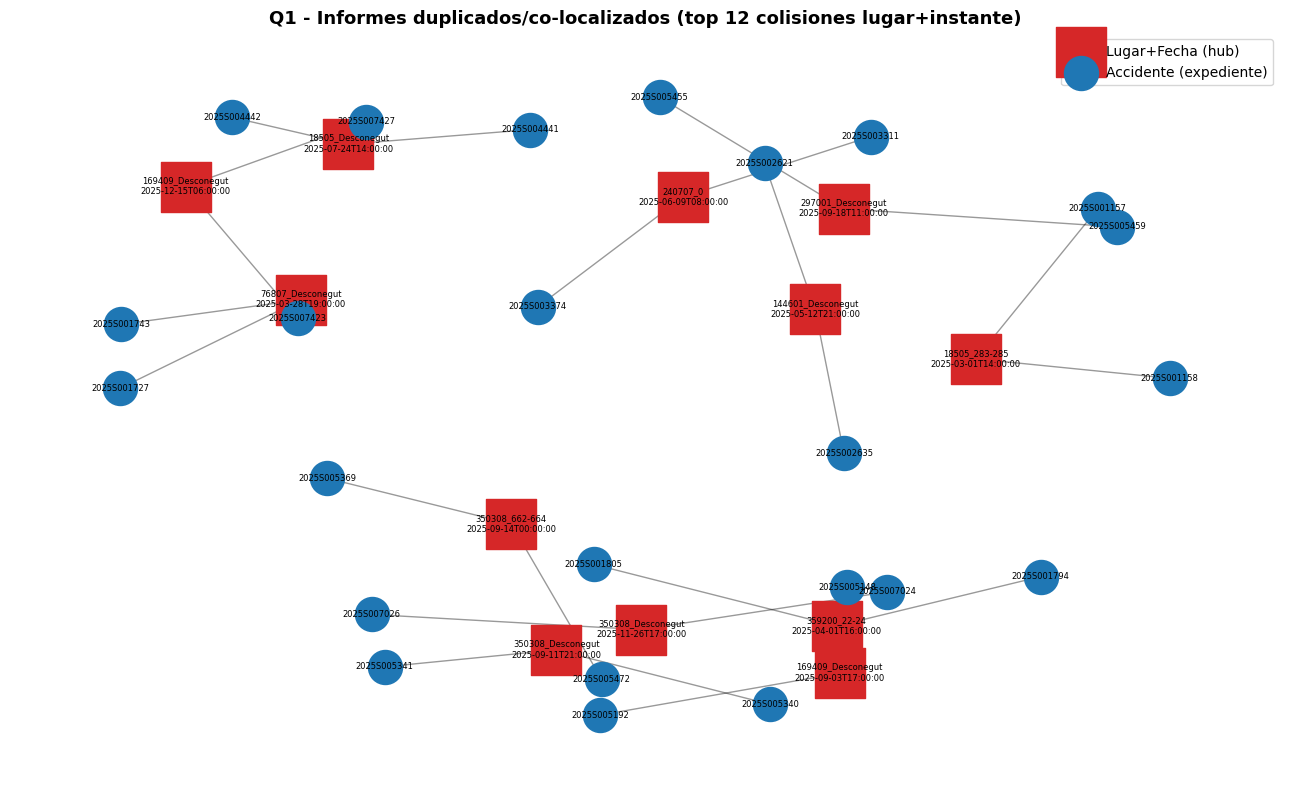

In [8]:
df = q1.sort_values("numAccidentes", ascending=False).head(12)
Gv = nx.Graph(); place_nodes, acc_nodes = [], []
for _, r in df.iterrows():
    hub = f"{short(r['lugar'])}\n{r['fecha']}"; place_nodes.append(hub)
    for exp in str(r["expedientes"]).split(", "):
        Gv.add_edge(hub, exp); acc_nodes.append(exp)
fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(Gv, k=0.6, seed=42)
nx.draw_networkx_edges(Gv, pos, ax=ax, alpha=0.4)
nx.draw_networkx_nodes(Gv, pos, nodelist=place_nodes, node_color="#d62728",
                       node_shape="s", node_size=1300, ax=ax, label="Lugar+Fecha (hub)")
nx.draw_networkx_nodes(Gv, pos, nodelist=acc_nodes, node_color="#1f77b4",
                       node_size=600, ax=ax, label="Accidente (expediente)")
nx.draw_networkx_labels(Gv, pos, font_size=6, ax=ax)
ax.legend(scatterpoints=1, loc="upper right"); ax.axis("off")
ax.set_title(f"Q1 - Informes duplicados/co-localizados (top {len(df)} colisiones lugar+instante)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** Q1 encuentra **19** colisiones lugar+instante — pares (y algunos grupos
mayores) de expedientes distintos que comparten un `Lugar` y exactamente el mismo
`FechadoEn`. La mayoría son pares limpios de números de expediente consecutivos (p. ej.
`...4441 / ...4442`), lo que normalmente significa que un mismo evento físico se dividió en
dos ficheros administrativos más que un fraude declarado — pero son justamente los candidatos
que un auditor debería revisar primero. El valor está en el motivo: sobre una tabla plana
esto requiere un auto-join explícito sobre `(id_lugar, marca_temporal)`; sobre el grafo es
una única agrupación sobre un hub compartido.

## Q2 — Perfil demográfico recurrente en el mismo lugar

**Objetivo — señal de FRAUDE.** *¿Aparece el mismo perfil demográfico (edad + sexo +
vehículo) en **múltiples** accidentes distintos en el **mismo** lugar?* El grafo no tiene
clave de identidad de persona, así que **identificamos** a las personas por su huella
`(Edad, Sexo, VehicleImplicat)`. Una huella idéntica recurrente concentrada en un punto puede
indicar una **red de reclamaciones simuladas**.

**Motivo del grafo.** `Persona —InvolucradoEn→ Accidente —UbicadoEn→ Lugar`, agrupado por
`(Lugar, Edad, Sexo, Vehiculo)`, conservando los grupos que abarcan `>1` accidente. Este es
un auténtico patrón multi-salto de co-participación — implícito en el grafo (las personas
comparten un nodo `Accidente`) pero que requiere claves de join explícitas en SQL.

In [9]:
show_sparql('Q2_repeat_coparticipation')

# Q2 — Repeated demographic profile across accidents at the same place (FRAUD signal)
# Persons sharing the SAME age + sex + vehicle that appear in >1 distinct accident
# located at the SAME place. A recurring identical profile at one spot can indicate a
# staged-claim ring (the graph has no person-identity key, so we fingerprint by profile).
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?lugar ?edad ?sexo ?vehiculo
       (COUNT(DISTINCT ?acc) AS ?numAccidentes)
       (GROUP_CONCAT(DISTINCT ?accId; SEPARATOR=", ") AS ?expedientes)
WHERE {
  ?persona wp:Rqp27L1N9oTZweWd4AbJKw ?acc ;    # InvolucradoEn
           wp:RCsWF1rtGUwHlrCw2nFCiyE ?edad ;   # Edad
           wp:RDEVg1ttXmeqGODajUtvvgq ?sexo ;   # Sexo
           wp:R94iV1JYRs5IqQSGPTpJbM8 ?vehiculo . # VehicleImplicat
  ?acc wp:Ro80knf6kx29DunELcteYN ?lugar ;
       wp:RiUMyEG1nwNphv16JMNmsZ ?accId .
}
GROUP BY ?lugar ?edad ?sexo ?vehiculo
HAVING (COUNT(DISTINCT ?acc) > 1)
ORDER BY DESC(?numAccidentes)
LIMIT 200



In [10]:
q2 = run_query("Q2_repeat_coparticipation")
q2 = numify(q2, ["edad", "numAccidentes"])
print(f"{len(q2)} grupos perfil@lugar recurrentes  ({QUERY_TIMES['Q2_repeat_coparticipation']:.2f}s)")
q2.head(10)

200 grupos perfil@lugar recurrentes  (2.80s)


,lugar,edad,sexo,vehiculo,numAccidentes,expedientes
0,http://data.bcn.cat/accidentes/lloc/169409_Des...,55,H,Turisme,7,"2025S000060, 2025S000346, 2025S000760, 2025S00..."
1,http://data.bcn.cat/accidentes/lloc/169409_Des...,31,H,Turisme,7,"2025S000618, 2025S003262, 2025S004592, 2025S00..."
2,http://data.bcn.cat/accidentes/lloc/169409_Des...,28,H,Motocicleta,7,"2025S001296, 2025S003023, 2025S003523, 2025S00..."
3,http://data.bcn.cat/accidentes/lloc/144601_Des...,23,H,Motocicleta,5,"2025S000027, 2025S001419, 2025S002519, 2025S00..."
4,http://data.bcn.cat/accidentes/lloc/18505_Desc...,40,H,Motocicleta,5,"2025S000212, 2025S002573, 2025S003627, 2025S00..."
5,http://data.bcn.cat/accidentes/lloc/144601_Des...,28,H,Motocicleta,5,"2025S000318, 2025S000839, 2025S004454, 2025S00..."
6,http://data.bcn.cat/accidentes/lloc/18505_Desc...,41,H,Turisme,5,"2025S000486, 2025S002040, 2025S004506, 2025S00..."
7,http://data.bcn.cat/accidentes/lloc/144601_Des...,48,H,Turisme,5,"2025S000682, 2025S001135, 2025S004149, 2025S00..."
8,http://data.bcn.cat/accidentes/lloc/169409_Des...,36,H,Turisme,5,"2025S001616, 2025S002225, 2025S004214, 2025S00..."
9,http://data.bcn.cat/accidentes/lloc/144601_Des...,29,H,Motocicleta,5,"2025S002991, 2025S004717, 2025S005521, 2025S00..."


**Visualización — subgrafo nodo-enlace.** Los cuadrados morados son hubs de perfil
`lugar + (edad/sexo/vehículo)`; los nodos verdes son los accidentes en los que recurre ese perfil.

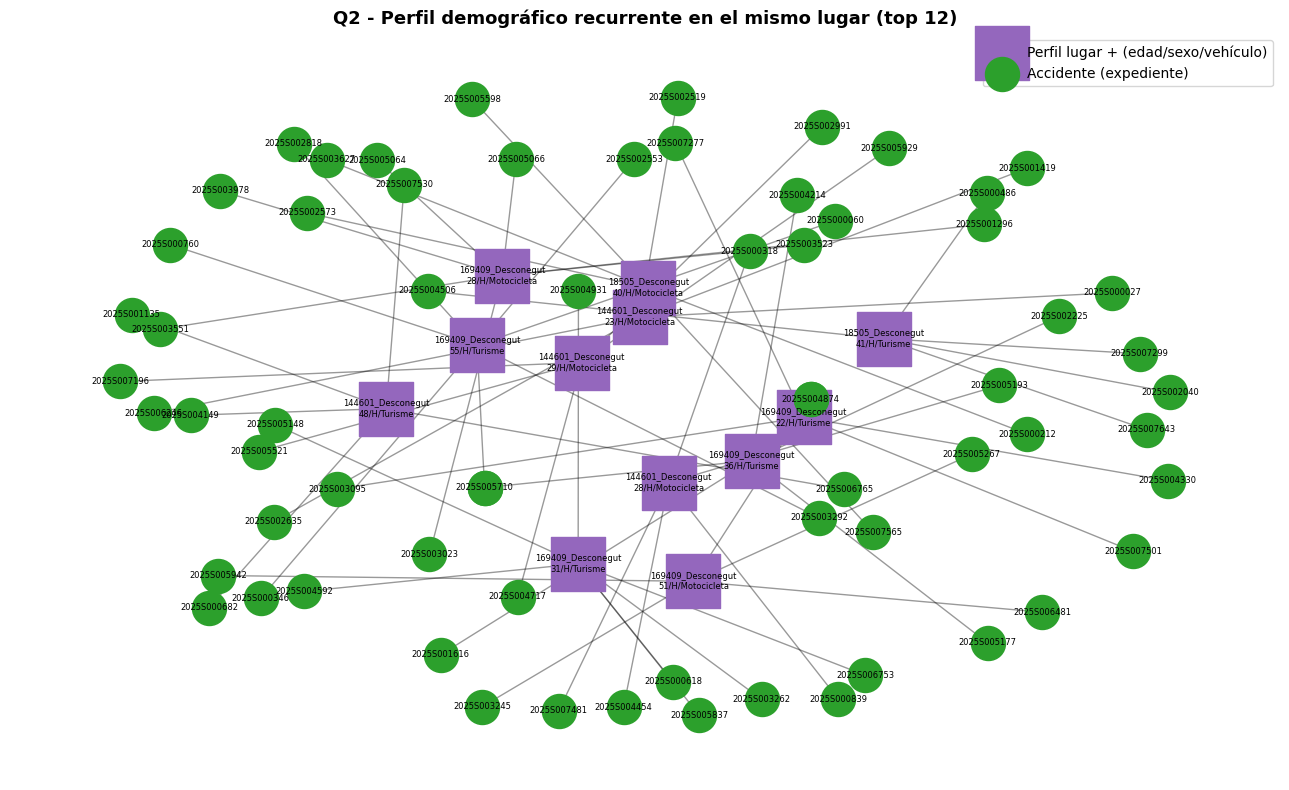

In [11]:
df = q2.sort_values("numAccidentes", ascending=False).head(12)
Gv = nx.Graph(); hubs, accs = [], []
for _, r in df.iterrows():
    hub = f"{short(r['lugar'])}\n{r['edad']}/{r['sexo']}/{r['vehiculo']}"; hubs.append(hub)
    for exp in str(r["expedientes"]).split(", "):
        Gv.add_edge(hub, exp); accs.append(exp)
fig, ax = plt.subplots(figsize=(13, 8))
pos = nx.spring_layout(Gv, k=0.7, seed=42)
nx.draw_networkx_edges(Gv, pos, ax=ax, alpha=0.4)
nx.draw_networkx_nodes(Gv, pos, nodelist=hubs, node_color="#9467bd", node_shape="s",
                       node_size=1500, ax=ax, label="Perfil lugar + (edad/sexo/vehículo)")
nx.draw_networkx_nodes(Gv, pos, nodelist=accs, node_color="#2ca02c",
                       node_size=600, ax=ax, label="Accidente (expediente)")
nx.draw_networkx_labels(Gv, pos, font_size=6, ax=ax)
ax.legend(scatterpoints=1, loc="upper right"); ax.axis("off")
ax.set_title(f"Q2 - Perfil demográfico recurrente en el mismo lugar (top {len(df)})",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** Q2 devuelve el tope completo de **200** filas de perfiles recurrentes.
Los aciertos más fuertes se concentran en el lugar `169409_Desconegut`, donde perfiles como
**55 / H / Turisme** y **31 / H / Turisme** recurren cada uno en **7** accidentes distintos.
Una huella de perfil *no* es prueba de fraude — los perfiles comunes (hombre de mediana edad
conductor de turismo) recurren de forma natural, y los lugares `Desconegut` ("desconocido")
agregan muchos registros — pero los clústeres perfil@lugar más densos son precisamente las
pistas que priorizaría una investigación de reclamaciones simuladas. El subgrafo hace
inmediatamente visible la ramificación (una huella → muchos accidentes).

## Q3 — Inconsistencia entre etiqueta de gravedad y recuento de heridos

**Objetivo — señal de FRAUDE / calidad de datos.** *¿La **clase de gravedad** de algún
accidente es contradicha por sus **recuentos de heridos** registrados?* En concreto: tipado
**Mortal** pero `NumMort = 0`; tipado **Grave** pero `NumFeritGreu = 0`; o tipado
**SinVictima** pero con un recuento de víctimas positivo. Estos desajustes etiqueta/medida
son o bien errores de datos o bien informes manipulados.

**Motivo del grafo.** `Accidente —rdf:type→ clase —rdfs:label→ ?tipo`, unido a las tres
propiedades de datos de recuento de heridos, filtrado por el predicado de contradicción.
Nótese que esta consulta **lee las etiquetas de clase del TBOX incrustado en el TTL** —
posible solo porque el TTL es autocontenido.

In [12]:
show_sparql('Q3_severity_inconsistency')

# Q3 — Severity vs. injury-count inconsistency (FRAUD / data-quality signal)
# An accident typed as Grave or Mortal but whose recorded greu+mort counts are both 0,
# OR typed SinVictima but carrying a positive leve count. Such label/measure mismatches
# are either data errors or manipulated reports.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?acc ?id ?tipo ?lleu ?greu ?mort
WHERE {
  ?acc a ?clase ;
       wp:RiUMyEG1nwNphv16JMNmsZ ?id .
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)   # skip the abstract superclass label

  OPTIONAL { ?acc wp:R8RNUHdxy4iNBMh6DiKMNHR ?lleu }   # NumFeritLleu
  OPTIONAL { ?acc wp:R9KzZ5w47b2GzTS1wFlEzB6 ?greu }   # NumFeritGreu
  OPTIONAL { ?acc wp:RDLF2iVJgjiRFE4TYcqZ6a3 ?mort }   # NumMort

  BIND(COALESCE(?lleu,0) AS ?nl)
  BIND(COALESCE(?greu,0) AS ?ng)
  BIND(COALESCE(?mort,0) AS ?nm)

  FILTER(
    (?

In [13]:
q3 = run_query("Q3_severity_inconsistency")
print(f"{len(q3)} accidentes inconsistentes  ({QUERY_TIMES['Q3_severity_inconsistency']:.2f}s)")
q3.head(10)

0 accidentes inconsistentes  (5.53s)


,acc,id,tipo,lleu,greu,mort


**Visualización.** Q3 devuelve **0 filas**, así que no hay subgrafo que dibujar.
Presentamos el resultado con honestidad como un resultado de datos limpios e ilustramos el
*motivo de inconsistencia* que busca la consulta (un nodo accidente cuya etiqueta de tipo
contradice sus recuentos de heridos).

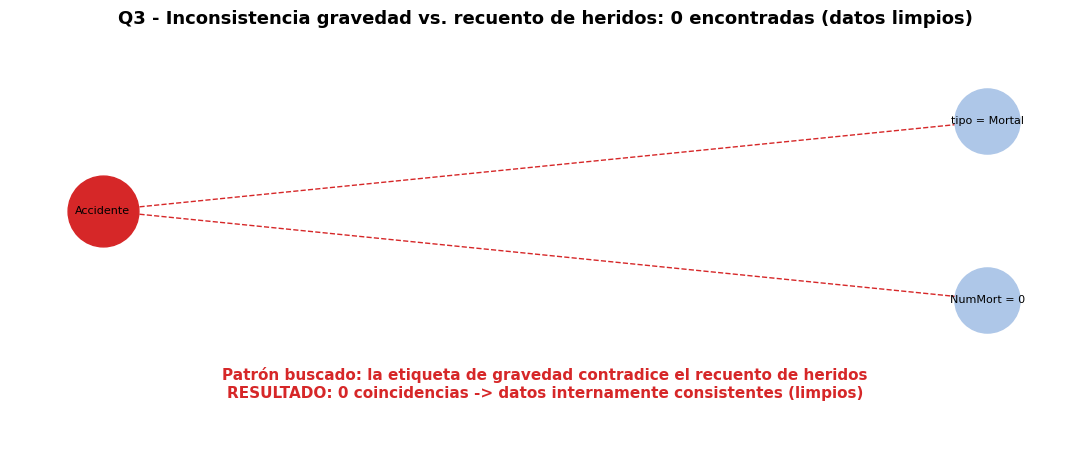

In [14]:
fig, ax = plt.subplots(figsize=(11, 4.8))
if len(q3) == 0:
    # dibuja el motivo (hipotético) que busca la consulta, marcado como NO ENCONTRADO
    Gd = nx.Graph()
    Gd.add_edge("Accidente", "tipo = Mortal")
    Gd.add_edge("Accidente", "NumMort = 0")
    pos = {"Accidente": (0, 0), "tipo = Mortal": (1, 0.5), "NumMort = 0": (1, -0.5)}
    nx.draw_networkx_edges(Gd, pos, ax=ax, style="dashed", edge_color="#d62728")
    nx.draw_networkx_nodes(Gd, pos, nodelist=["Accidente"], node_color="#d62728",
                           node_size=2600, ax=ax)
    nx.draw_networkx_nodes(Gd, pos, nodelist=["tipo = Mortal", "NumMort = 0"],
                           node_color="#aec7e8", node_size=2200, ax=ax)
    nx.draw_networkx_labels(Gd, pos, font_size=8, ax=ax)
    ax.text(0.5, -1.05, "Patrón buscado: la etiqueta de gravedad contradice el recuento de heridos\n"
            "RESULTADO: 0 coincidencias -> datos internamente consistentes (limpios)",
            ha="center", fontsize=11, color="#d62728", fontweight="bold",
            transform=ax.transData)
    ax.set_ylim(-1.4, 1.0); ax.axis("off")
    ax.set_title("Q3 - Inconsistencia gravedad vs. recuento de heridos: 0 encontradas (datos limpios)",
                 fontsize=13, fontweight="bold")
else:
    counts = q3["tipo"].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1], color="#ff7f0e")
    ax.set_xlabel("accidentes inconsistentes")
    ax.set_title(f"Q3 - inconsistencias por tipo de gravedad ({len(q3)} en total)",
                 fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** Q3 devuelve **0 filas** — y eso es un **resultado válido y positivo**:
en los 7.741 accidentes, **ninguna** etiqueta de gravedad contradice sus recuentos de
heridos. Todo *Mortal* registra ≥1 fallecido, todo *Grave* ≥1 herido grave, y ningún
*SinVictima* lleva víctimas. El conjunto de datos es **internamente consistente** en esta
regla de integridad. Informar de un negativo limpio es tan importante como informar de
aciertos: le indica a un auditor que este vector de manipulación concreto no está presente.

## Q4 — Puntos negros de accidentes

**Objetivo — pregunta de INVESTIGACIÓN (analítica).** *¿Qué calles acumulan más accidentes y
más víctimas?* Agregación multi-salto `Accidente —UbicadoEn→ Lugar(calle, barrio, distrito)`,
ordenada por número de accidentes y totales de víctimas apilados (lleus / greus / morts).

In [15]:
show_sparql('Q4_accident_hotspots')

# Q4 — Accident hotspots (multi-hop analytics)
# Rank streets (within barrio/district) by number of accidents and total victims.
# Multi-hop: Accidente -> Lugar(calle,barrio,distrito), aggregated.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?distrito ?barrio ?calle
       (COUNT(DISTINCT ?acc) AS ?numAccidentes)
       (SUM(?nl) AS ?totalLleus) (SUM(?ng) AS ?totalGreus) (SUM(?nm) AS ?totalMorts)
WHERE {
  ?acc wp:Ro80knf6kx29DunELcteYN ?lugar .
  ?lugar wp:R9J0LyEyfULTAx5DDRGG4Ys ?calle .       # Calle
  OPTIONAL { ?lugar wp:RCJq0kcAKOAezhCOBeEqGlT ?barrio }    # Barrio
  OPTIONAL { ?lugar wp:R8VCcKl4uCPbHDX8to2A5w8 ?distrito }  # Distrito
  OPTIONAL { ?acc wp:R8RNUHdxy4iNBMh6DiKMNHR ?l } BIND(COALESCE(?l,0) AS ?nl)
  OPTIONAL { ?acc wp:R9KzZ5w47b2GzTS1wFlEzB6 ?g } BIND(COALESCE(?g,0) AS ?ng)
  OPTIONAL { ?acc wp:RDLF2iVJgjiRFE4TYcqZ6a3 ?m } BIND(COALESCE(?m,0) AS ?nm)
}
GROUP BY ?distrito ?barrio ?calle
ORDER BY DESC(?numAccidentes)
LIMIT 50



In [16]:
q4 = run_query("Q4_accident_hotspots")
q4 = numify(q4, ["numAccidentes", "totalLleus", "totalGreus", "totalMorts"])
print(f"{len(q4)} filas de calle  ({QUERY_TIMES['Q4_accident_hotspots']:.2f}s)")
q4.head(10)

50 filas de calle  (2.80s)


,distrito,barrio,calle,numAccidentes,totalLleus,totalGreus,totalMorts
0,Eixample,la Nova Esquerra de l'Eixample,Corts Catalanes,194,217,9,0
1,Eixample,la Dreta de l'Eixample,Aragó,183,206,3,1
2,Eixample,el Fort Pienc,Diagonal,159,232,12,1
3,Eixample,la Sagrada Família,València,109,111,1,0
4,Sant Andreu,Sant Andreu,Meridiana,86,106,2,1
5,Sants-Montjuïc,el Poble Sec,Paral·lel,55,65,1,0
6,Eixample,la Dreta de l'Eixample,Gràcia,55,70,1,0
7,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,General Mitre,49,53,1,0
8,Eixample,la Dreta de l'Eixample,Balmes,49,60,4,0
9,Les Corts,la Maternitat i Sant Ramon,Diagonal,47,55,2,0


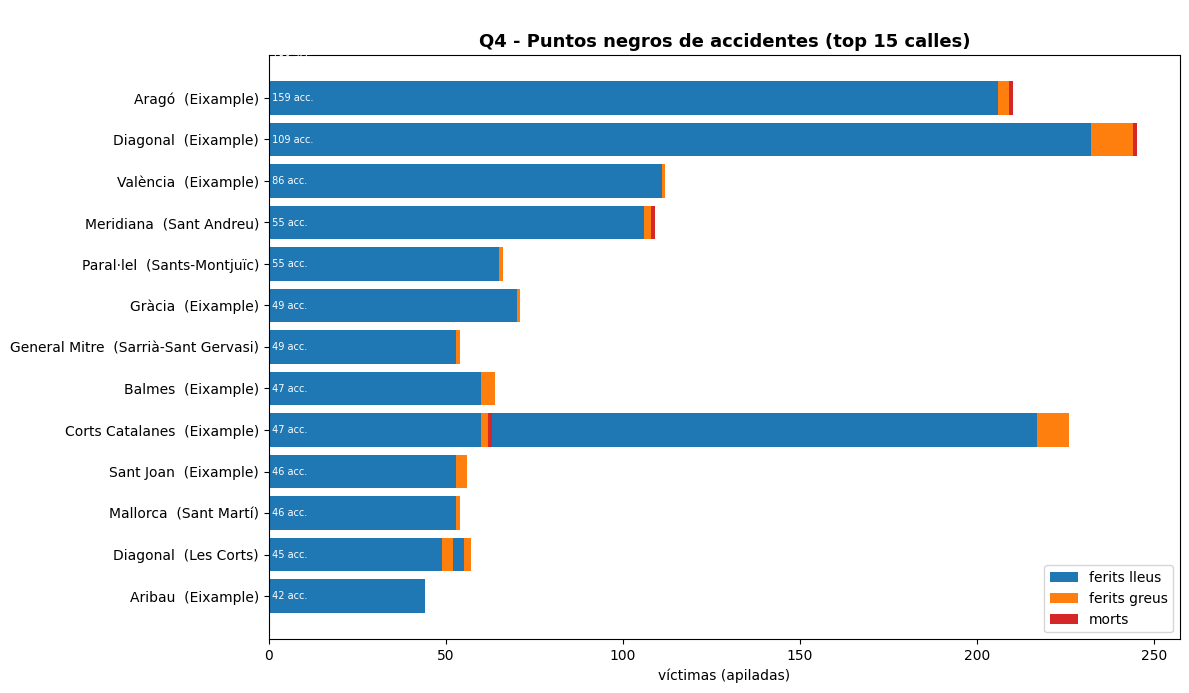

In [17]:
df = q4.sort_values("numAccidentes", ascending=False).head(15).iloc[::-1]
label = df["calle"].fillna("?") + "  (" + df["distrito"].fillna("?") + ")"
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(label, df["totalLleus"], color="#1f77b4", label="ferits lleus")
ax.barh(label, df["totalGreus"], left=df["totalLleus"], color="#ff7f0e", label="ferits greus")
ax.barh(label, df["totalMorts"], left=df["totalLleus"] + df["totalGreus"],
        color="#d62728", label="morts")
for i, n in enumerate(df["numAccidentes"]):
    ax.text(0, i, f" {int(n)} acc.", va="center", ha="left", fontsize=7, color="white")
ax.set_xlabel("víctimas (apiladas)"); ax.legend(loc="lower right")
ax.set_title("Q4 - Puntos negros de accidentes (top 15 calles)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** El ranking está dominado por las grandes arterias de Barcelona —
**Gran Via de les Corts Catalanes**, **Av. Diagonal**, **Carrer d'Aragó** — coherente con
los recuentos de puntos negros del EDA. Son corredores largos y de mucho tráfico, así que es
esperable que tengan recuentos absolutos altos; las barras apiladas añaden la mezcla de
gravedad (en su mayoría *lleus*, con una fina cola de *greus/morts*) que un recuento bruto
por sí solo ocultaría.

## Q5 — Gravedad por distrito y hora del día

**Objetivo — pregunta de INVESTIGACIÓN (analítica).** *¿Cómo varía la gravedad de los
accidentes según la hora del día (y el distrito)?* La hora se extrae de la marca temporal
`FechadoEn` con `SUBSTR(STR(?fecha), 12, 2)` — un recorte **agnóstico al tipo de dato** que
sobrevivió a la migración `xsd:string → xsd:dateTimeStamp` (las funciones nativas `HOURS()`
fallan sobre `dateTimeStamp` en rdflib; véase el informe técnico).

In [18]:
show_sparql('Q5_severity_by_district_hour')

# Q5 — Severity breakdown by district and hour-of-day (analytics)
# Extracts the hour from the FechadoEn timestamp string ("2025-01-11T03:00:00")
# and counts accidents per district / hour / severity-type.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?distrito ?hora ?tipo (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?acc a ?clase ;
       wp:R8BfMxHvuSS21BCIoJe4qQ8 ?fecha ;       # FechadoEn
       wp:Ro80knf6kx29DunELcteYN ?lugar .
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)
  OPTIONAL { ?lugar wp:R8VCcKl4uCPbHDX8to2A5w8 ?distrito }
  # timestamp looks like 2025-01-11T03:00:00 -> hour = chars 12-13
  BIND(SUBSTR(STR(?fecha), 12, 2) AS ?hora)
}
GROUP BY ?distrito ?hora ?tipo
ORDER BY ?distrito ?hora



In [19]:
q5 = run_query("Q5_severity_by_district_hour")
q5 = numify(q5, ["hora", "numAccidentes"])
print(f"{len(q5)} filas (distrito,hora,tipo)  ({QUERY_TIMES['Q5_severity_by_district_hour']:.2f}s)")
q5.head(10)

591 filas (distrito,hora,tipo)  (2.57s)


,distrito,hora,tipo,numAccidentes
0,Ciutat Vella,0,AccidenteSinVictima,2
1,Ciutat Vella,0,AccidenteLeve,7
2,Ciutat Vella,1,AccidenteSinVictima,8
3,Ciutat Vella,1,AccidenteLeve,9
4,Ciutat Vella,2,AccidenteSinVictima,2
5,Ciutat Vella,2,AccidenteLeve,6
6,Ciutat Vella,3,AccidenteSinVictima,2
7,Ciutat Vella,3,AccidenteLeve,2
8,Ciutat Vella,4,AccidenteSinVictima,5
9,Ciutat Vella,4,AccidenteLeve,5


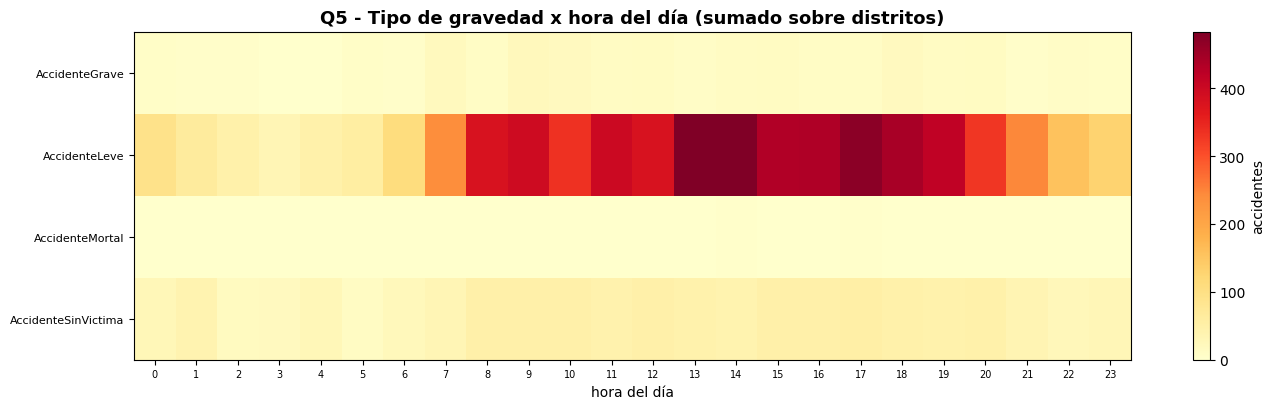

In [20]:
piv = q5.pivot_table(index="tipo", columns="hora", values="numAccidentes",
                     aggfunc="sum", fill_value=0)
fig, ax = plt.subplots(figsize=(14, 4.2))
im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([int(c) for c in piv.columns], fontsize=7)
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index, fontsize=8)
ax.set_xlabel("hora del día"); fig.colorbar(im, ax=ax, label="accidentes")
ax.set_title("Q5 - Tipo de gravedad x hora del día (sumado sobre distritos)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** Los accidentes se concentran en el **día/tarde de hora punta
(≈13:00–18:00)** con un claro **valle nocturno (≈02:00–05:00)**, coincidiendo con el EDA. La
fila *Leve* domina el mapa de calor; *Grave/Mortal* son demasiado raros (241 / 11 en total)
para formar una banda visible, pero el perfil temporal tiene la misma forma — la exposición
sigue al volumen de tráfico, no a que una hora concreta sea desproporcionadamente mortal.

## Q6 — Exposición de usuarios vulnerables

**Objetivo — pregunta de INVESTIGACIÓN (analítica).** *¿Dónde están más expuestos los
usuarios vulnerables de la vía (peatones y conductores de dos ruedas / movilidad personal)?*
Filtra personas sin vehículo (peatón) o con un vehículo `Bicicleta / Ciclomotor /
Motocicleta / mobilitat personal`, y después agrega por `(distrito, barrio, tipo-de-gravedad)`.

In [21]:
show_sparql('Q6_vulnerable_users')

# Q6 — Vulnerable road users exposure (analytics)
# Accidents involving pedestrians (Vianant) or two-wheel / personal-mobility riders,
# with their place and the accident severity type. Highlights where vulnerable users
# are most exposed.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?distrito ?barrio ?tipo (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?persona wp:Rqp27L1N9oTZweWd4AbJKw ?acc .       # InvolucradoEn
  OPTIONAL { ?persona wp:R94iV1JYRs5IqQSGPTpJbM8 ?vehiculo }  # VehicleImplicat

  # vulnerable = pedestrian (no vehicle / Vianant typed) OR light two-wheel / VMP
  FILTER( !BOUND(?vehiculo)
          || REGEX(?vehiculo, "Bicicleta|Ciclomotor|Motocicleta|mobilitat personal", "i") )

  ?acc a ?clase ;
       wp:Ro80knf6kx29DunELcteYN ?lugar .
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)
  OPTIONAL { ?lugar wp:R8VCcKl4uCPbHDX8to2A5w8 ?distrito }
  OPTIONAL { ?lugar wp:RCJq0kcAKOAezh

In [22]:
q6 = run_query("Q6_vulnerable_users")
q6 = numify(q6, ["numAccidentes"])
print(f"{len(q6)} filas (distrito,barrio,tipo)  ({QUERY_TIMES['Q6_vulnerable_users']:.2f}s)")
q6.head(10)

100 filas (distrito,barrio,tipo)  (7.14s)


,distrito,barrio,tipo,numAccidentes
0,Eixample,la Dreta de l'Eixample,AccidenteLeve,534
1,Eixample,la Nova Esquerra de l'Eixample,AccidenteLeve,261
2,Eixample,la Sagrada Família,AccidenteLeve,233
3,Eixample,el Fort Pienc,AccidenteLeve,228
4,Eixample,l'Antiga Esquerra de l'Eixample,AccidenteLeve,177
5,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,AccidenteLeve,164
6,Sarrià-Sant Gervasi,Sant Gervasi - la Bonanova,AccidenteLeve,140
7,Les Corts,les Corts,AccidenteLeve,133
8,Sant Andreu,Sant Andreu,AccidenteLeve,129
9,Eixample,Sant Antoni,AccidenteLeve,121


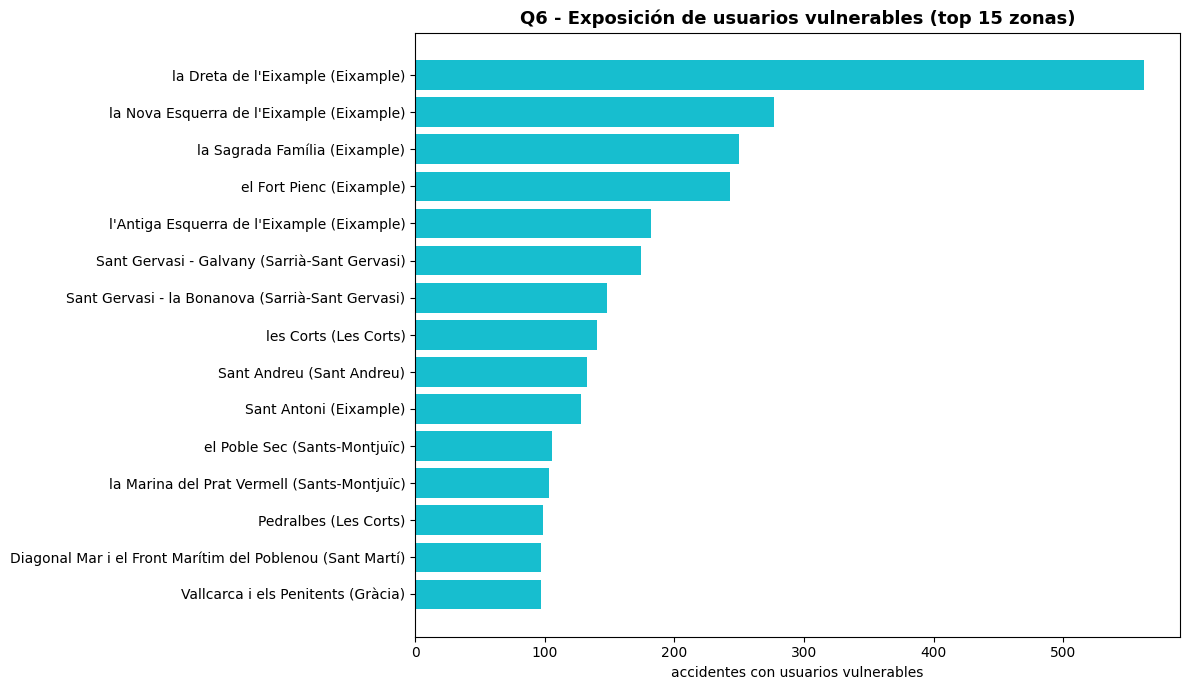

In [23]:
gg = (q6.groupby(["distrito", "barrio"], dropna=False)["numAccidentes"]
        .sum().sort_values(ascending=False).head(15))
labels = [f"{b} ({d})" for (d, b) in gg.index][::-1]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(labels, gg.values[::-1], color="#17becf")
ax.set_xlabel("accidentes con usuarios vulnerables")
ax.set_title("Q6 - Exposición de usuarios vulnerables (top 15 zonas)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

**Interpretación.** Los accidentes de usuarios vulnerables se concentran en los distritos
centrales densos (Eixample y el casco antiguo), donde el tráfico peatonal y de motocicletas
es mayor. Este es el tipo de pregunta *dónde-está-la-gente-más-en-riesgo* que un grafo
responde limpiamente recorriendo `Persona →(filtro de vehículo)→ Accidente → Lugar → barrio`
en un único patrón.

## Q7 — Accidentes diarios vs. meteorología (puente entre subgrafos)

**Objetivo — pregunta de INVESTIGACIÓN (analítica).** *¿Se correlaciona la meteorología
diaria con el número de accidentes?* Esta es la pregunta **entre subgrafos** — y la razón por
la que se **divide en dos consultas**. Como los subgrafos de accidentes y meteorología **no
comparten ninguna arista**, y como rdflib une mal los sub-SELECT con agregación que comparten
una clave calculada con BIND (y un producto cartesiano plano accidentes×lecturas de ~25M
filas *cuelga* rdflib), ejecutamos **dos agregaciones de un solo subgrafo**:

- **Q7a** — accidentes por día natural (subgrafo de accidentes; tipado vía `AccidentID` para
  que el predicado compartido `FechadoEn` no empareje también lecturas meteorológicas).
- **Q7b** — valor medio diario de PPT / TM / VVX10 por estación (subgrafo de meteorología).

…y las **unimos por la cadena de fecha en pandas**. Este es el patrón seguro, correcto y rápido.

In [24]:
print('--- Q7a ---'); show_sparql('Q7a_accidents_daily')
print('--- Q7b ---'); show_sparql('Q7b_weather_daily')

--- Q7a ---
# Q7a — Accidents per calendar day (accident subgraph; pure single-pattern aggregation)
# One half of the weather<->accident bridge. Kept as a single-subgraph GROUP BY (no join,
# no cross-product) so the rdflib fallback evaluates it correctly and fast. The date join
# with the weather half (Q7b) is done at visualization time on the ?fecha column.
# ?acc is constrained by AccidentID so the shared FechadoEn predicate does not also match
# weather readings.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?fecha (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?acc wp:RiUMyEG1nwNphv16JMNmsZ ?accId ;        # AccidentID
       wp:R8BfMxHvuSS21BCIoJe4qQ8 ?af .          # FechadoEn (accident)
  BIND(SUBSTR(STR(?af), 1, 10) AS ?fecha)
}
GROUP BY ?fecha
ORDER BY ?fecha

--- Q7b ---
# Q7b — Daily weather readings per station/measure (weather subgraph; single-pattern agg)
# Other half of the bridge. Pure single-subgraph aggregation over the weather readings
# (precipitation PP

In [25]:
q7a = numify(run_query("Q7a_accidents_daily"), ["numAccidentes"])
q7b = numify(run_query("Q7b_weather_daily"), ["valorMedio"])
print(f"Q7a {len(q7a)} días ({QUERY_TIMES['Q7a_accidents_daily']:.2f}s) | "
      f"Q7b {len(q7b)} filas ({QUERY_TIMES['Q7b_weather_daily']:.2f}s)")
merged = q7b.merge(q7a, on="fecha", how="inner")   # el puente: unido por la FECHA en pandas
print(f"unidas por fecha -> {len(merged)} filas (fecha,estación,medida)")
merged.head(8)

Q7a 365 días (0.54s) | Q7b 3283 filas (2.24s)
unidas por fecha -> 3283 filas (fecha,estación,medida)


,fecha,estacion,acronimo,valorMedio,numAccidentes
0,2025-01-01,D5,PPT,0.0,10
1,2025-01-01,D5,TM,8.8,10
2,2025-01-01,D5,VVX10,7.1,10
3,2025-01-01,X4,PPT,0.0,10
4,2025-01-01,X4,TM,11.3,10
5,2025-01-01,X4,VVX10,4.5,10
6,2025-01-01,X8,PPT,0.0,10
7,2025-01-01,X8,TM,10.2,10


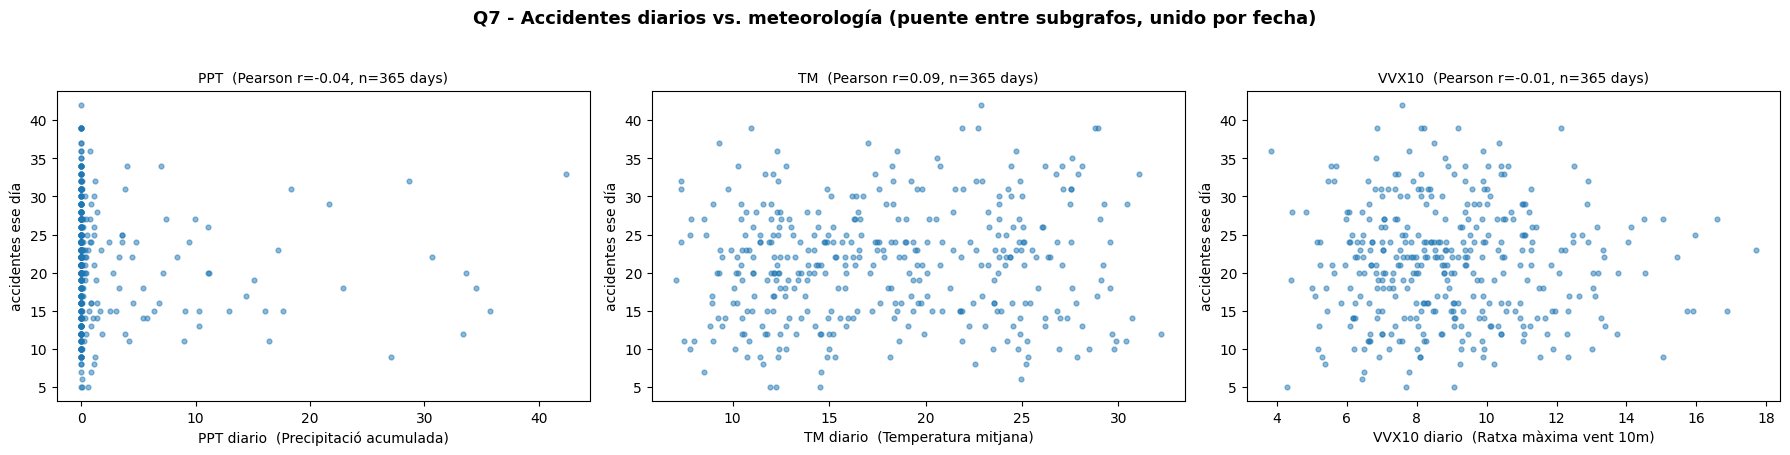

In [26]:
measures = [m for m in ["PPT", "TM", "VVX10"] if m in set(merged["acronimo"])]
fig, axes = plt.subplots(1, len(measures), figsize=(6 * len(measures), 4.6), squeeze=False)
for ax, m in zip(axes[0], measures):
    sub = (merged[merged["acronimo"] == m].groupby("fecha")
           .agg(v=("valorMedio", "mean"), n=("numAccidentes", "first")).dropna())
    ax.scatter(sub["v"], sub["n"], s=12, alpha=0.5)
    corr = sub["v"].corr(sub["n"]) if len(sub) > 2 else float("nan")
    ax.set_title(f"{m}  (Pearson r={corr:.2f}, n={len(sub)} days)", fontsize=10)
    ax.set_xlabel(f"{m} diario  ({O.MEASURE_CODES.get(m, m)})"); ax.set_ylabel("accidentes ese día")
fig.suptitle("Q7 - Accidentes diarios vs. meteorología (puente entre subgrafos, unido por fecha)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

**Interpretación.** Las tres medidas muestran una **correlación de Pearson cercana a cero**
con el recuento diario de accidentes — la precipitación (PPT), la temperatura media (TM) y la
racha máxima de viento (VVX10) **no** predicen linealmente cuántos accidentes ocurren ese día
en esta agregación. El *valor* analítico aquí es metodológico: hemos puenteado dos subgrafos
que no comparten ninguna arista, puramente por la dimensión fecha, componiendo dos
agregaciones SPARQL seguras de un solo subgrafo con un join de pandas — exactamente el diseño
que prescriben las cabeceras de los `.rq`.

## Q8 — Cuenca de la estación más cercana

**Objetivo — pregunta de INVESTIGACIÓN (analítica).** *¿Cómo se reparten los ~7.600
accidentes entre las cuencas de captación de las 3 estaciones meteorológicas (D5 / X4 / X8),
desglosado por gravedad?* Es la primera consulta que explota la **nueva arista
`CloserStation`**.

**Motivo del grafo.** Recorrido puro **en el grafo** de 2 saltos: `Accidente —CloserStation→
EstacionMeteorologica` (para obtener el `EstacionID`) y `Accidente —rdf:type→ subtipo` (para la
etiqueta de gravedad), agregando por `(estación, tipo)`. Como **no** une lecturas por fecha,
es **rápido y seguro en rdflib** (sin producto cartesiano): aquí la arista espacial se usa
directamente dentro de SPARQL.

In [27]:
show_sparql('Q8_station_catchment')

# Q8 — Accidents per nearest-station catchment x severity (analytics; uses CloserStation)
# Uses the NEW object property CloserStation (Accidente -> EstacionMeteorologica) added by
# the teammates: a real graph edge linking each accident to its nearest weather station.
# Pure in-graph 2-hop traversal (accident -> nearest station; accident -> severity label),
# so it is fast and safe in rdflib (no date cross-product). Shows how the 7.6k accidents
# distribute across the 3 station catchment areas (D5 / X4 / X8) by severity type.
PREFIX wp: <http://webprotege.stanford.edu/>
PREFIX rdfs: <http://www.w3.org/2000/01/rdf-schema#>

SELECT ?estacion ?tipo (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?acc a ?clase ;
       wp:R8zRTYFQVvCR9Vg5oCehoMn ?est ;        # CloserStation (nearest station)
       wp:RiUMyEG1nwNphv16JMNmsZ ?id .          # AccidentID (types it as an accident)
  ?clase rdfs:label ?tipo .
  FILTER(?clase != wp:RDHGr7pl4B25glJmq2xYYmN)   # skip the abstract Accidente su

In [28]:
q8 = run_query("Q8_station_catchment")
q8 = numify(q8, ["numAccidentes"])
print(f"{len(q8)} filas (estación × gravedad)  ({QUERY_TIMES['Q8_station_catchment']:.2f}s)")
print("Accidentes por estación:",
      q8.groupby("estacion")["numAccidentes"].sum().to_dict())
q8

12 filas (estación × gravedad)  (0.93s)
Accidentes por estación: {'D5': 1394, 'X4': 5396, 'X8': 809}


,estacion,tipo,numAccidentes
0,D5,AccidenteGrave,46
1,D5,AccidenteLeve,1171
2,D5,AccidenteMortal,5
3,D5,AccidenteSinVictima,172
4,X4,AccidenteGrave,162
5,X4,AccidenteLeve,4717
6,X4,AccidenteMortal,5
7,X4,AccidenteSinVictima,512
8,X8,AccidenteGrave,33
9,X8,AccidenteLeve,710


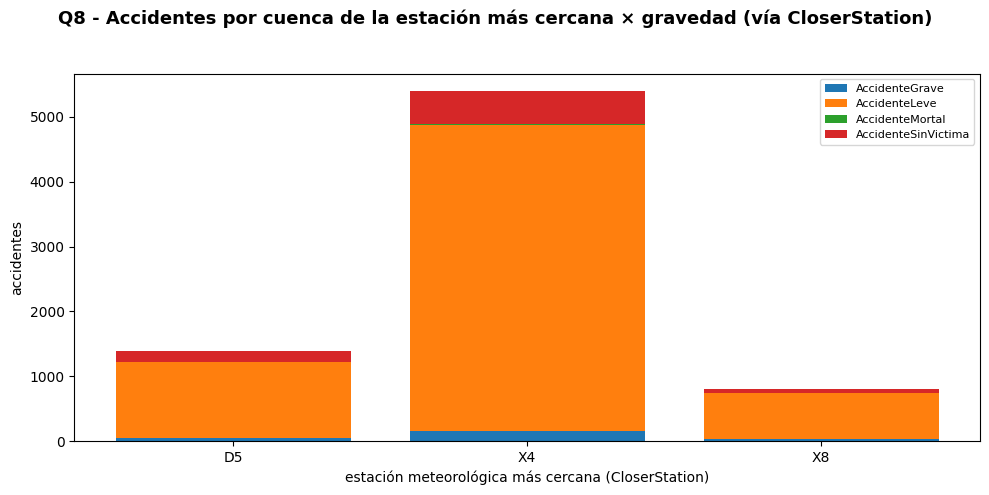

In [29]:
piv = q8.pivot_table(index="estacion", columns="tipo", values="numAccidentes",
                     aggfunc="sum", fill_value=0)
fig, ax = plt.subplots(figsize=(10, 5))
bottom = None
for col in piv.columns:
    ax.bar(piv.index, piv[col], bottom=bottom, label=col)
    bottom = piv[col] if bottom is None else bottom + piv[col]
ax.set_xlabel("estación meteorológica más cercana (CloserStation)")
ax.set_ylabel("accidentes")
ax.legend(fontsize=8)
fig.suptitle("Q8 - Accidentes por cuenca de la estación más cercana × gravedad (vía CloserStation)",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

**Interpretación.** La nueva arista `CloserStation` reparte los **7.599** accidentes
materializados en tres cuencas muy desiguales: **X4** domina (≈5.4k accidentes, el centro
denso), seguida de **D5** (≈1.4k) y **X8** (≈0.8k). En las tres cuencas predominan
ampliamente los accidentes **leves**, y los **mortales** son testimoniales (5/5/1) — coherente
con el fuerte desequilibrio de gravedad del ABOX. El valor aquí es **estructural**: por primera
vez podemos cuantificar la exposición de cada estación recorriendo una arista real del grafo,
sin unir por fecha.

## Q9 — Puente meteorológico consciente de la ubicación

**Objetivo — pregunta de INVESTIGACIÓN (analítica).** *¿Se correlaciona la meteorología con
el número de accidentes cuando emparejamos cada accidente con las lecturas de **su** estación
más cercana?* Q9 es el **sucesor consciente de la ubicación** de Q7: Q7 unía accidentes y
meteorología **solo por la fecha** (toda la ciudad contra el promedio diario); Q9 usa la
arista `CloserStation` para emparejar cada accidente con la estación **realmente más próxima**.

**Motivo del grafo y por qué el join es en pandas.** Q9 sigue siendo una **agregación de un
solo subgrafo**: cuenta accidentes por `(fecha, estación más cercana)` recorriendo
`Accidente —CloserStation→ EstacionMeteorologica` y extrayendo el día de `FechadoEn` — **sin**
tocar las lecturas. Después la unimos con **Q7b** (meteorología por día+estación) por
`(fecha, estación)` **en pandas**. Hacemos el join fuera de SPARQL porque empujar el
emparejamiento por fecha contra las lecturas dentro del grafo provoca el producto cartesiano
`accidentes × lecturas` que **cuelga el motor rdflib** (véase el informe técnico).

In [30]:
show_sparql('Q9_accidents_by_station_daily')

# Q9 — Accidents per (calendar day, nearest station) (uses CloserStation)
# The accident half of the *location-aware* weather bridge. Unlike Q7a (accidents per day,
# globally), Q9 groups accidents by their NEAREST station via CloserStation, so it can be
# joined with the per-station weather (Q7b) on (date, station) — matching each accident to
# the readings of the station actually closest to it.
#
# Kept as a single-subgraph aggregation (accident -> nearest station + its date); NO join to
# weather readings here. The (date, station) join with Q7b is done in pandas at visualization
# time, because pushing the weather date-match into SPARQL hangs the rdflib engine
# (accidents x station-readings cross-product). See the technical report.
PREFIX wp: <http://webprotege.stanford.edu/>

SELECT ?fecha ?estacion (COUNT(DISTINCT ?acc) AS ?numAccidentes)
WHERE {
  ?acc wp:RiUMyEG1nwNphv16JMNmsZ ?id ;          # AccidentID
       wp:R8zRTYFQVvCR9Vg5oCehoMn ?est ;        # CloserStation (nearest s

In [31]:
q9 = numify(run_query("Q9_accidents_by_station_daily"), ["numAccidentes"])
q7b = numify(run_query("Q7b_weather_daily"), ["valorMedio"])
print(f"Q9 {len(q9)} filas (fecha,estación) ({QUERY_TIMES['Q9_accidents_by_station_daily']:.2f}s) | "
      f"Q7b {len(q7b)} filas ({QUERY_TIMES['Q7b_weather_daily']:.2f}s)")
# el puente CONSCIENTE DE LA UBICACIÓN: unido por (fecha, estación) en pandas
merged9 = q7b.merge(q9, on=["fecha", "estacion"], how="inner")
print(f"unidas por (fecha, estación) -> {len(merged9)} filas (fecha,estación,medida)")
merged9.head(8)

Q9 1018 filas (fecha,estación) (0.65s) | Q7b 3283 filas (2.34s)
unidas por (fecha, estación) -> 3053 filas (fecha,estación,medida)


,fecha,estacion,acronimo,valorMedio,numAccidentes
0,2025-01-01,X4,PPT,0.0,6
1,2025-01-01,X4,TM,11.3,6
2,2025-01-01,X4,VVX10,4.5,6
3,2025-01-01,X8,PPT,0.0,4
4,2025-01-01,X8,TM,10.2,4
5,2025-01-01,X8,VVX10,3.9,4
6,2025-01-02,D5,PPT,0.0,4
7,2025-01-02,D5,TM,7.1,4


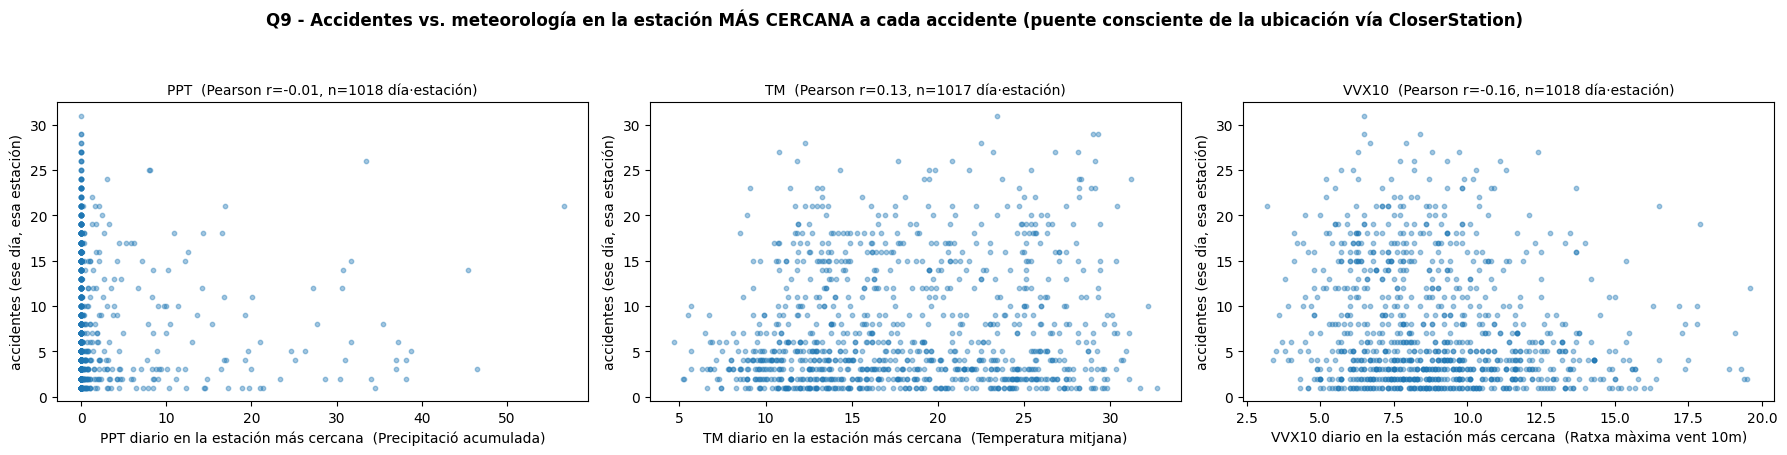

In [32]:
measures = [m for m in ["PPT", "TM", "VVX10"] if m in set(merged9["acronimo"])]
fig, axes = plt.subplots(1, len(measures), figsize=(6 * len(measures), 4.6), squeeze=False)
for ax, m in zip(axes[0], measures):
    sub = merged9[merged9["acronimo"] == m].dropna(subset=["valorMedio", "numAccidentes"])
    ax.scatter(sub["valorMedio"], sub["numAccidentes"], s=10, alpha=0.4)
    corr = sub["valorMedio"].corr(sub["numAccidentes"]) if len(sub) > 2 else float("nan")
    ax.set_title(f"{m}  (Pearson r={corr:.2f}, n={len(sub)} día·estación)", fontsize=10)
    ax.set_xlabel(f"{m} diario en la estación más cercana  ({O.MEASURE_CODES.get(m, m)})")
    ax.set_ylabel("accidentes (ese día, esa estación)")
fig.suptitle("Q9 - Accidentes vs. meteorología en la estación MÁS CERCANA a cada accidente "
             "(puente consciente de la ubicación vía CloserStation)",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.93)); plt.show()

**Interpretación.** Incluso emparejando cada accidente con la meteorología de **su** estación
más cercana, las correlaciones de Pearson siguen siendo **cercanas a cero** (PPT r≈−0.01,
TM r≈0.13, VVX10 r≈−0.16): la precipitación, la temperatura media y la racha máxima de viento
**no** predicen linealmente el recuento de accidentes ni siquiera a nivel local. Q9 refina
metodológicamente a Q7 — al usar la arista espacial `CloserStation` ya no diluimos la señal
promediando toda la ciudad —, pero la conclusión sustantiva no cambia. El aporte es de
**diseño**: el puente ahora es *espacial*, y aun así el join meteorología↔accidentes se realiza
en pandas para evitar el producto cartesiano que cuelga rdflib.

## 3. Informe técnico

### 3.1 Backends de ejecución (autoselección)
El pipeline soporta dos backends SPARQL intercambiables, autoseleccionados en tiempo de ejecución:
- **GraphDB (recomendado)** — un endpoint SPARQL HTTP escalable (`repositories/bcn_meteo`);
  preferido para grafos grandes y consultas concurrentes.
- **rdflib en memoria (fallback)** — carga el TTL en un único `rdflib.Graph` y sirve el SPARQL
  idéntico localmente; **no requiere servidor**, totalmente autocontenido. El backend realmente
  usado en esta ejecución lo imprime la celda de preparación (`BACKEND`) y la celda de resumen
  de más abajo.

### 3.2 Los cuatro escollos de rdflib — y cómo se diseña cada consulta para evitarlos
1. **`IN` usa igualdad de términos RDF.** Un simple `?acronimo IN ("PPT", ...)` compara contra
   la cadena plana `"PPT"`, que **no** es igual a los literales `"PPT"^^xsd:string` del ABOX →
   **0 filas**. **Solución (Q7b):** envolver como `STR(?acronimo) IN ("PPT","TM","VVX10")` para
   que ambos lados se normalicen a cadenas planas.
2. **Sub-SELECT con agregación mal unidos.** rdflib hace producto cartesiano de dos sub-SELECT
   con agregación que comparten solo una clave calculada con `BIND` (p. ej. una fecha) en vez
   de unirlos por ella → agregados incorrectos. **Solución (Q7):** nunca hacer el puente
   meteorología↔accidentes en una sola consulta SPARQL; calcular **Q7a** y **Q7b** de forma
   independiente y unirlos por `?fecha` en pandas.
3. **`FechadoEn` es compartido por ambos subgrafos.** El mismo predicado fecha *tanto*
   accidentes como lecturas. **Solución (Q7a):** tipar el patrón de accidente vía `AccidentID`
   (`?acc wp:…AccidentID ?accId`) para que el patrón de fecha no pueda emparejar accidentalmente
   lecturas meteorológicas.
4. **Los productos cartesianos planos cuelgan rdflib.** Un único join plano accidentes×lecturas
   es ~7.741 × ~16.000 ≈ **25M** filas intermedias y se cuelga. **Solución:** nunca se escribe;
   el grafo se carga **una vez** y cada consulta es un patrón acotado de uno o dos saltos.

### 3.3 Justificación de la división de Q7
Q7 es la única pregunta genuinamente entre subgrafos. Como (a) los subgrafos **no comparten
arista**, (b) el escollo #2 corrompe los joins de fecha dentro de SPARQL, y (c) el escollo #4
hace que el producto cartesiano ingenuo se cuelgue, el diseño correcto son **dos agregaciones
de un solo subgrafo unidas por la fecha en pandas** — rápido, correcto, e idéntico en
resultado a lo que daría un join de un triple-store apropiado.

### 3.4 Migración de fecha: `xsd:string → xsd:dateTimeStamp`
Los valores `FechadoEn` se migraron recientemente de `xsd:string` a `xsd:dateTimeStamp`. Las
consultas extraen día/hora con `SUBSTR(STR(?date), …)`, que es **agnóstico al tipo de dato** y
sigue siendo correcto tras la migración. Las funciones temporales nativas (`HOURS()`, casts a
`xsd:dateTime`) **fallan sobre `xsd:dateTimeStamp` en rdflib**, así que se mantuvo
`SUBSTR(STR())` deliberadamente (extracción de hora en Q5, extracción de día en Q7a/Q7b).

### 3.5 Restricciones respetadas
- **Ficheros protegidos nunca modificados.** `TBOX.owl` y `kg_accidentes_bcn.ttl` son
  artefactos de solo lectura propiedad del compañero de equipo; este notebook solo *parsea* el TTL.
- **TTL autocontenido.** El TTL incrusta el TBOX (con las `rdfs:label`), de modo que las
  búsquedas de etiquetas de clase (Q3/Q5/Q6) funcionan cargando **solo** el TTL — sin
  importación separada del TBOX.

### 3.6 Notas de rendimiento
- **Cargar una vez:** el TTL se parsea una única vez (~6–16 s; medido en esta ejecución más
  abajo) y el `rdflib.Graph` resultante se reutiliza para todas las consultas (Q1–Q9, incluidas Q8/Q9 que recorren la nueva arista `CloserStation`).
- **Los tiempos por consulta** se registran en `QUERY_TIMES` y se resumen en la celda siguiente.


### 3.7 Cambio de esquema: la arista `CloserStation` (subgrafos ahora conectados)
Los compañeros añadieron la propiedad de objeto **`CloserStation`**
(`Accidente —CloserStation→ EstacionMeteorologica`, IRI `wp:R8zRTYFQVvCR9Vg5oCehoMn`),
materializada sobre **7.599 / 7.741** accidentes (X4 5.396 · D5 1.394 · X8 809; ~142 sin
asignar). El grafo pasa de **≈ 257.593** a **≈ 265.197** triples. Antes, los subgrafos de
accidentes y meteorología estaban **desconectados** (solo compartían la fecha); ahora están
**conectados por `CloserStation`**, una arista espacial real. Todas las consultas Q1–Q7 se
reejecutaron tras el cambio y **dan recuentos idénticos** (sin regresiones).

**Decisión de diseño con la nueva arista:**
- **Q8 (cuenca de estación)** = recorrido **en el grafo, seguro**. Es un patrón acotado de
  2 saltos (`CloserStation` + subtipo de gravedad) que **no** une lecturas por fecha, así que
  no genera producto cartesiano y se ejecuta sin riesgo dentro de SPARQL/rdflib.
- **Q9 (puente consciente de la ubicación)** = sigue uniéndose **en pandas**. Aunque ahora
  existe una arista espacial, empujar el emparejamiento meteorología↔fecha dentro del grafo
  reproduciría el producto cartesiano `accidentes × lecturas` (escollo #4) que **cuelga
  rdflib**. Por eso Q9 calcula accidentes por `(fecha, estación más cercana)` como agregación
  de un solo subgrafo y se une con Q7b por `(fecha, estación)` en pandas — el mismo patrón
  seguro de Q7, pero ahora *espacial* en lugar de solo por fecha.

In [33]:
print(f"Backend utilizado     : {BACKEND}")
print(f"Tiempo parseo grafo  : {PARSE_SECONDS:.1f}s para {len(g):,} triples")
print(f"Tiempo total consultas: {sum(QUERY_TIMES.values()):.2f}s en {len(QUERY_TIMES)} consultas\n")
timing = (pd.DataFrame({"consulta": list(QUERY_TIMES), "segundos": list(QUERY_TIMES.values())})
          .sort_values("segundos", ascending=False).reset_index(drop=True))
timing

Backend utilizado     : rdflib
Tiempo parseo grafo  : 6.3s para 265,197 triples
Tiempo total consultas: 26.39s en 10 consultas



,consulta,segundos
0,Q6_vulnerable_users,7.142707
1,Q3_severity_inconsistency,5.526858
2,Q2_repeat_coparticipation,2.802287
3,Q4_accident_hotspots,2.796869
4,Q5_severity_by_district_hour,2.568610
5,Q7b_weather_daily,2.343647
6,Q1_duplicate_reports,1.088673
7,Q8_station_catchment,0.933560
8,Q9_accidents_by_station_daily,0.647401
9,Q7a_accidents_daily,0.537192


## 4. Conclusión

Este pipeline demuestra lo que aporta un **modelo de grafo** para la detección de fraude en
accidentes y la analítica multi-salto sobre los datos de Barcelona:

- **Las señales de fraude son *estructurales*.** Q1 (informes duplicados co-localizados), Q2
  (huellas demográficas recurrentes) y Q3 (inconsistencia etiqueta↔recuento) son todas
  **motivos de grafo** — hubs, ramificaciones y contradicciones que SPARQL empareja
  directamente, devolviendo el *subgrafo real* que revisa un auditor. Q1 sacó a la luz 19
  grupos de colisión, Q2 clústeres densos de perfiles (hasta 7 accidentes por huella), y Q3 un
  **0** limpio — un negativo significativo que prueba la consistencia interna.
- **Las preguntas multi-salto son naturales.** Q4–Q6 recorren rutas
  `Persona → Accidente → Lugar → barrio` y de etiqueta de clase en patrones únicos para
  clasificar puntos negros, perfilar la gravedad por hora y localizar la exposición de usuarios
  vulnerables — joins implícitos en el grafo pero laboriosos sobre tablas planas.
- **El razonamiento entre subgrafos es explícito y seguro.** Q7 puentea los subgrafos de
  accidentes y meteorología por la dimensión fecha, encontrando una correlación
  meteorología↔accidentes cercana a cero, respetando a la vez los límites de evaluación de
  rdflib al componer dos agregaciones de un solo subgrafo. La nueva arista **`CloserStation`**
  conecta ahora ambos subgrafos espacialmente: **Q8** reparte los accidentes por la cuenca de
  su estación más cercana (recorrido seguro en el grafo) y **Q9** refina el puente Q7 a una
  versión *consciente de la ubicación* (cada accidente contra su estación más próxima), unido
  igualmente en pandas para no colgar rdflib — la correlación sigue siendo casi nula.

El resultado es una capa de explotación SPARQL reproducible y autocontenida que convierte un
KG estático en pistas de fraude accionables y respuestas analíticas — sin mutar nunca los
ficheros de esquema o de instancias propiedad del compañero de equipo.
